# Red neuronal predictiva
**NOTA : este cuaderno describe un primer entrenamiento del modelo predictivo, en la carpeta de ajuste de hiperparámetros se hará el entrenamiento con el modelo final.**

El Algoritmo Genético necesita una forma rápida de saber qué pasaría si cambia el caudal o la temperatura. Para eso entrenaremos una Red Neuronal. Para ello necesitamos entrenar un modelo basado en ANN que tome como entrada las variables features y prediga con alta los outputs, recordemos:
- features: [T_in_leche, F_flow, T_servicio, t_ciclo, Delta_P]
- targets: [E_consumo, T_out_leche]

Vamos a basar nuestro desarrollo en el articulo de Yang et al. (2023) sobre la rotura de nueces asistida por secado. Su metodología híbrida GA-ANN (Algoritmo Genético + Red Neuronal Artificial) es excelente y perfectamente extrapolable a nuestro proceso de pasteurización. A continuación añado una descripción de su metodología y como va a implementarse en nuestro proceso de pasteurización.

### Preparación de Datos y Topología Base

**Metodología del paper**: Dividieron el dataset en 80% para entrenamiento y 20% para testeo, y normalizaron las variables de entrada al rango (-1, 1). Utilizaron una red feed-forward (BP-ANN) con tres capas: entrada, oculta y salida. Las capas ocultas usaron funciones de activación sigmoidales (tansig o logsig), mientras que la capa de salida usó una función lineal (purelin). Es decir, emplearon una red neuronal artificial densa normal.

***Nuestra adaptación (Datagia)***: * Usaremos nuestro split temporal (definido en tu EDA) respetando la secuencia del proceso, en lugar de un split aleatorio 80/20.
- Aplicaremos el MinMaxScaler [0,1] que ya decidiste en tu Notebook 2.
- Capa de entrada: 5 neuronas (T_in_leche, F_flow, T_servicio, t_ciclo, Delta_P).
- Capa de salida: 2 neuronas (Función lineal para predecir E_consumo y T_out_leche).

### Búsqueda de la Topología Óptima

**Metodología del paper**: No eligieron el número de neuronas ocultas al azar. Calcularon un rango (de 1 a 13) usando fórmulas empíricas (basadas en el número de entradas y salidas) y probaron todas las combinaciones haciendo 10 simulaciones por topología para evitar sesgos. La arquitectura óptima se eligió buscando el máximo $R^2$ y el mínimo RMSE.

**Nuestra adaptación (Datagia)**: Gemini indica que lo más óptimo es lo siguiente: *Aplicaremos fórmulas empíricas similares. Como tenemos 5 entradas y 2 salidas, el rango inicial teórico de neuronas ocultas estará entre 3 y 15. Haremos un bucle de entrenamiento iterativo variando el número de neuronas y las funciones de activación (probaremos Sigmoide, ReLU y Tanh) y nos quedaremos con la topología que minimice el RMSE en validación.* Sin embargo, yo seguramente prefiera desarrollar una metodologia tradicional con una optimización de hiperparámetros

### El truco clave: Inicialización de Pesos con Algoritmo Genético (GA-ANN)

En el paper emlean un Ga para establecer los pesos iniciales de la red, esto probablemente sea redunante en nuetro caso por lo que no haremos.

**Metodología del paper**: Detectaron que la red neuronal estándar (BP) dependía demasiado de los pesos y umbrales (sesgos) iniciales generados aleatoriamente, cayendo fácilmente en mínimos locales. Para solucionarlo, usaron un GA en el que la "función de aptitud" (fitness) era el error de la red neuronal. El GA buscó los pesos y umbrales iniciales óptimos, y solo entonces se entrenó la red neuronal. Esto redujo el RMSE final drásticamente (hasta un 50% de mejora frente a la red estándar).

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import json
import joblib
import os
from pathlib import Path
import matplotlib.pyplot as plt
import copy
import random

In [ ]:
# --- 1. CONTROL DE REPRODUCIBILIDAD  ---
def set_seed(seed=1):
    """Fija todas las semillas para garantizar la reproducibilidad exacta."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(1)
print("✅ Semillas aleatorias fijadas (Reproducibilidad garantizada).")

✅ Semillas aleatorias fijadas (Reproducibilidad garantizada).


In [ ]:
# --- 2. REQUISITOS DE EJECUCIÓN CPU/GPU ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Dispositivo de ejecución detectado: {device}")

✅ Dispositivo de ejecución detectado: cpu


In [ ]:
# --- RUTAS RELATIVAS (Desde notebooks/training/) ---
DATA_PATH = "../../data/processed/final_data_sim.csv"
MODEL_DIR = "../../models/artifacts"
METRICS_DIR = "../../models/metrics"

# Crear carpetas si no existen
os.makedirs("../../data/splits", exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

print("Rutas configuradas correctamente.")

Rutas configuradas correctamente.


In [ ]:
print("Cargando datos...")
df = pd.read_csv(DATA_PATH)

# Filtrar limpieza y ordenar temporalmente
if 'Is_Cleaning' in df.columns:
    df = df[df['Is_Cleaning'] == 0].copy()
df = df.sort_values(by='Time_min').reset_index(drop=True)

features = ['T_in_leche', 'F_flow', 'T_servicio', 't_ciclo', 'Delta_P']
targets = ['E_consumo', 'T_out_leche']

Cargando datos...


In [ ]:
# 2. Split temporal estratificado por bloques (4 cuartiles)
n_bloques = 4
chunk_size = len(df) // n_bloques

X_train_list, X_val_list, X_test_list = [], [], []
y_train_list, y_val_list, y_test_list = [], [], []

for i in range(n_bloques):
    start_idx = i * chunk_size
    end_idx = (i + 1) * chunk_size if i < n_bloques - 1 else len(df)
    chunk = df.iloc[start_idx:end_idx]
    
    # Índices para 70% train, 15% val, 15% test DENTRO del bloque
    train_idx = int(len(chunk) * 0.70)
    val_idx = int(len(chunk) * 0.85)
    
    X_chunk = chunk[features].values
    y_chunk = chunk[targets].values
    
    X_train_list.append(X_chunk[:train_idx])
    X_val_list.append(X_chunk[train_idx:val_idx])
    X_test_list.append(X_chunk[val_idx:])
    
    y_train_list.append(y_chunk[:train_idx])
    y_val_list.append(y_chunk[train_idx:val_idx])
    y_test_list.append(y_chunk[val_idx:])

# Concatenar los bloques
X_train = np.vstack(X_train_list)
X_val = np.vstack(X_val_list)
X_test = np.vstack(X_test_list)
y_train = np.vstack(y_train_list)
y_val = np.vstack(y_val_list)
y_test = np.vstack(y_test_list)

print(
    f"Datos cargados y divididos: {X_train.shape[0]} train, "
    f"{X_val.shape[0]} val, {X_test.shape[0]} test."
)

Datos cargados y divididos: 35980 train, 7712 val, 7712 test.


In [ ]:
# 3. Normalización MinMaxScaler [0,1] (FIT SOLO EN TRAIN)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)
y_test_scaled = scaler_y.transform(y_test)

# 4. Convertir a Tensores de PyTorch
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train_scaled)

X_val_t = torch.FloatTensor(X_val_scaled)
y_val_t = torch.FloatTensor(y_val_scaled)

X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.FloatTensor(y_test_scaled)

print(f"Train (70%): X={X_train_t.shape}, y={y_train_t.shape}")
print(f"Validación (15%): X={X_val_t.shape}, y={y_val_t.shape}")
print(f"Test (15%): X={X_test_t.shape}, y={y_test_t.shape}")

Train (70%): X=torch.Size([35980, 5]), y=torch.Size([35980, 2])
Validación (15%): X=torch.Size([7712, 5]), y=torch.Size([7712, 2])
Test (15%): X=torch.Size([7712, 5]), y=torch.Size([7712, 2])


In [ ]:
class PasteurizationMLP(nn.Module):
    def __init__(self, input_size, output_size):
        super(PasteurizationMLP, self).__init__()
        # Arquitectura fija: Entrada -> 32 -> ReLU -> 32 -> ReLU -> Salida
        self.net = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, output_size)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
# Instanciar el modelo, la función de pérdida y el optimizador
model = PasteurizationMLP(input_size=len(features), output_size=len(targets))
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Configuración de Early Stopping y gráficas
epochs = 300  # Subimos el máximo de épocas, el early stopping lo cortará antes si es necesario
patience = 20 # Si tras 20 épocas la validación no mejora, paramos
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

train_losses = []
val_losses = []

# Bucle de entrenamiento
for epoch in range(epochs):
    # --- FASE DE ENTRENAMIENTO ---
    model.train()
    optimizer.zero_grad()
    
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    # --- FASE DE VALIDACIÓN ---
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t)
        val_loss = criterion(val_preds, y_val_t).item()
        
    val_losses.append(val_loss)
    
    # --- EARLY STOPPING LOGIC ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Guardamos una copia exacta de los pesos en este momento óptimo
        best_model_state = copy.deepcopy(model.state_dict())
    else:
        epochs_no_improve += 1
        
    # Mostrar progreso cada 20 épocas
    if (epoch + 1) % 20 == 0:
        print(f"Época [{epoch+1}/{epochs}] | Train MSE: {loss.item():.6f} | Val MSE: {val_loss:.6f}")
        
    # Condición de parada
    if epochs_no_improve >= patience:
        print(f"\n🛑 Early Stopping disparado en la época {epoch+1}! Sin mejora durante {patience} épocas.")
        break

Época [20/300] | Train MSE: 0.009563 | Val MSE: 0.008200
Época [40/300] | Train MSE: 0.004494 | Val MSE: 0.004770
Época [60/300] | Train MSE: 0.002974 | Val MSE: 0.002857
Época [80/300] | Train MSE: 0.001174 | Val MSE: 0.001061
Época [100/300] | Train MSE: 0.000232 | Val MSE: 0.000230
Época [120/300] | Train MSE: 0.000122 | Val MSE: 0.000123
Época [140/300] | Train MSE: 0.000075 | Val MSE: 0.000076
Época [160/300] | Train MSE: 0.000053 | Val MSE: 0.000053
Época [180/300] | Train MSE: 0.000041 | Val MSE: 0.000042
Época [200/300] | Train MSE: 0.000035 | Val MSE: 0.000036
Época [220/300] | Train MSE: 0.000032 | Val MSE: 0.000032
Época [240/300] | Train MSE: 0.000029 | Val MSE: 0.000029
Época [260/300] | Train MSE: 0.000027 | Val MSE: 0.000027
Época [280/300] | Train MSE: 0.000025 | Val MSE: 0.000031
Época [300/300] | Train MSE: 0.000023 | Val MSE: 0.000024


In [ ]:
# Restaurar los mejores pesos encontrados (no los de la última época)
model.load_state_dict(best_model_state)
best_model = model

print(f"\n✅ Entrenamiento completado | Mejor Val MSE: {best_val_loss:.6f}")


✅ Entrenamiento completado | Mejor Val MSE: 0.000023


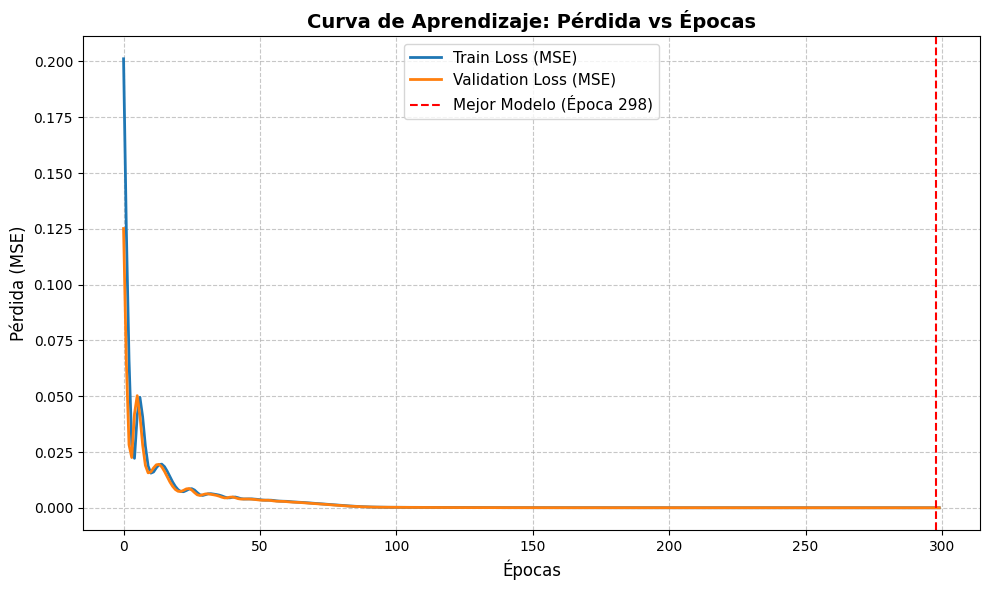

In [ ]:
# --- GRÁFICA DE APRENDIZAJE ---
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss (MSE)', color='#1f77b4', linewidth=2)
plt.plot(val_losses, label='Validation Loss (MSE)', color='#ff7f0e', linewidth=2)

# Línea vertical donde ocurrió el mejor modelo
mejor_epoca = len(train_losses) - epochs_no_improve
plt.axvline(x=mejor_epoca, color='red', linestyle='--', label=f'Mejor Modelo (Época {mejor_epoca})')

plt.title('Curva de Aprendizaje: Pérdida vs Épocas', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Pérdida (MSE)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Evaluamos el modelo final ÚNICAMENTE con el conjunto de Test
best_model.eval()
with torch.no_grad():
    preds_scaled = best_model(X_test_t).numpy()

# Desnormalizar predicciones para calcular métricas reales
preds_real = scaler_y.inverse_transform(preds_scaled)

rmse_e = np.sqrt(mean_squared_error(y_test[:, 0], preds_real[:, 0]))
rmse_t = np.sqrt(mean_squared_error(y_test[:, 1], preds_real[:, 1]))
r2_e = r2_score(y_test[:, 0], preds_real[:, 0])
r2_t = r2_score(y_test[:, 1], preds_real[:, 1])

metrics = {
    "architecture": "MLP_32x32",
    "E_consumo": {"RMSE": rmse_e, "R2": r2_e},
    "T_out_leche": {"RMSE": rmse_t, "R2": r2_t}
}

print("Métricas finales en datos de TEST (Nunca antes vistos):")
print(json.dumps(metrics, indent=4))

Métricas finales en datos de TEST (Nunca antes vistos):
{
    "architecture": "MLP_32x32",
    "E_consumo": {
        "RMSE": 0.47687373541706835,
        "R2": 0.9988718147637929
    },
    "T_out_leche": {
        "RMSE": 0.017716239013231914,
        "R2": 0.9985387593458634
    }
}
